In [27]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

import glob
import re
import os
import warnings

In [28]:
audio_path = "../data/Experimentos"

audio_files = glob.glob(audio_path + "/*.m4a") + \
              glob.glob(audio_path + "/*.wav") + \
              glob.glob(audio_path + "/*.mp3")

print(f"Archivos de audio encontrados: {len(audio_files)}")

Archivos de audio encontrados: 56


In [29]:
def load_and_clean_audio(audio_path):
    """Carga el audio en su SR nativo y asegura que sea mono float."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y, sr = librosa.load(audio_path, sr=None)
    
    if y.ndim > 1:
        y = np.mean(y, axis=1)
    
    t = np.linspace(0, len(y) / sr, num=len(y))
    return y, sr, t

def get_initial_clusters(y, sr, t, min_peak_ratio=0.05):
    """Detecta picos y los agrupa mediante ventana dinámica."""
    amax = np.max(np.abs(y))
    threshold = amax * min_peak_ratio
    
    # 1. Detección rápida
    peaks_pos, props_pos = find_peaks(y, height=threshold)
    peaks_neg, props_neg = find_peaks(-y, height=threshold)
    
    peaks_all = np.concatenate([peaks_pos, peaks_neg])
    amps_all = np.concatenate([props_pos["peak_heights"], props_neg["peak_heights"]])
    
    # 2. Ordenamiento íntegro
    order = np.argsort(peaks_all)
    peaks_all, amps_all = peaks_all[order], amps_all[order]
    
    # 3. Agrupamiento dinámico (Este bucle es necesario por su naturaleza recursiva)
    k, beta, min_w, max_w = 0.015, 0.5, 0.004, 0.020
    clusters = []
    if len(peaks_all) == 0:
        return np.array([]), np.array([]), np.array([])

    current_cl = [0]
    for i in range(1, len(peaks_all)):
        a_cluster = np.max(amps_all[current_cl])
        win_sec = np.clip(k * (a_cluster ** beta), min_w, max_w)
        if (peaks_all[i] - peaks_all[current_cl[-1]]) <= (win_sec * sr):
            current_cl.append(i)
        else:
            clusters.append(current_cl)
            current_cl = [i]
    clusters.append(current_cl)
    
    # 4. Selección del dominante (Vectorizado donde es posible)
    dom_peaks = []
    dom_amps = []
    for cl in clusters:
        cl_arr = np.array(cl)
        m_idx = cl_arr[np.argmax(amps_all[cl_arr])]
        dom_peaks.append(peaks_all[m_idx])
        dom_amps.append(amps_all[m_idx])
        
    return np.array(dom_peaks), np.array(dom_amps), t[dom_peaks]

def apply_rhythm_filters(peaks, amps, times):
    """Aplica filtros de magnitud y de aceleración (Δt) usando NumPy puro."""
    if len(times) < 3:
        return peaks, amps, times

    # --- Filtro 1.5x (Magnitud) ---
    # Comparamos cada pico con el siguiente
    shifted_amps = np.append(amps[1:], 0)
    mask_15 = ~(amps * 1.5 < shifted_amps)
    
    p, a, t = peaks[mask_15], amps[mask_15], times[mask_15]
    
    # --- Filtro Δt (Aceleración/Ritmo) ---
    if len(t) < 3: return p, a, t
    
    dts = np.diff(t)
    dt1 = dts[:-1] # Intervalo n
    dt2 = dts[1:]  # Intervalo n+1
    
    keep = np.ones(len(t), dtype=bool)
    # Si el intervalo siguiente es más largo, descartamos el pico n+2
    keep[2:] = ~(dt2 > dt1)
    
    return p[keep], a[keep], t[keep]

def extract_dominant_peaks(audio_path):
    """Función principal modularizada."""
    y, sr, t = load_and_clean_audio(audio_path)
    
    p_dom, a_dom, t_dom = get_initial_clusters(y, sr, t)
    
    f_peaks, f_amps, f_times = apply_rhythm_filters(p_dom, a_dom, t_dom)
    
    return t, y, sr, f_peaks, f_times, f_amps


In [ ]:
def compute_COR(audio_path):

    t , y, sr, _, dominant_times, _ = extract_dominant_peaks(audio_path)

    delta_t = np.diff(dominant_times)
    if len(delta_t) < 1:
        return None

    g = 9.80665
    h_n = 0.5 * g * (delta_t / 2)**2
    if len(h_n) < 2:
        return None

    ratios = np.sqrt(h_n[1:] / h_n[:-1])
    return np.mean(ratios)

def compute_COR_from_data(dominant_times):
    """Compute COR directly from dominant peak times (avoids reloading audio)."""
    delta_t = np.diff(dominant_times)
    if len(delta_t) < 1:
        return None

    g = 9.80665
    h_n = 0.5 * g * (delta_t / 2)**2
    if len(h_n) < 2:
        return None

    ratios = np.sqrt(h_n[1:] / h_n[:-1])
    return np.mean(ratios)

def plot_audio_peaks(audio_path):
    t, y, sr, dom_peaks, dom_times, dom_amps = extract_dominant_peaks(audio_path)

    N_show = int(1.0 * sr)

    plt.figure(figsize=(12, 5))
    plt.plot(t[:N_show], y[:N_show], label="Señal")

    mask = dom_peaks[dom_peaks < N_show]
    plt.scatter(t[mask], y[mask],
                color="yellow", edgecolor="black", s=80,
                label="Picos dominantes finales")

    plt.title(f"Picos dominantes finales\n{audio_path}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_audio_peaks_from_data(t, y, sr, dom_peaks, dom_times, dom_amps, title_suffix=""):
    """Plot peaks directly from pre-extracted data (avoids reloading audio)."""
    N_show = int(1.0 * sr)

    plt.figure(figsize=(12, 5))
    plt.plot(t[:N_show], y[:N_show], label="Señal")

    mask = dom_peaks[dom_peaks < N_show]
    plt.scatter(t[mask], y[mask],
                color="yellow", edgecolor="black", s=80,
                label="Picos dominantes finales")

    plt.title(f"Picos dominantes finales{title_suffix}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.show()

def group_COR_by_experiment(folder_path, verbose=True):
    """Group COR values by experiment number 'n' from filenames like C1-{n}h-{m}.ext
    
    Args:
        folder_path: Path to folder containing audio files
        verbose: Whether to print progress messages
        
    Returns:
        Dictionary with keys as 'n' values (strings) and values as lists of COR values
    """
    COR_groups = {}
    pattern = r"C1-(\d+)h-\d+\.(m4a|wav|mp3)$"

    for fname in sorted(os.listdir(folder_path)):
        match = re.match(pattern, fname)
        if not match:
            continue

        n_value = match.group(1)  # el "n" de C1-nh-m
        audio_file_path = os.path.join(folder_path, fname)

        COR = compute_COR(audio_file_path)

        if COR is None:
            if verbose:
                print(f"{audio_file_path} → COR = None (se omite)")
            continue

        if n_value not in COR_groups:
            COR_groups[n_value] = []

        COR_groups[n_value].append(COR)

        if verbose:
            print(f"{audio_file_path} → n={n_value} → COR = {COR}")

    if verbose:
        print("\n=== RESULTADOS AGRUPADOS POR n ===")
        for n in sorted(COR_groups, key=lambda x: int(x)):
            lista = COR_groups[n]
            print(f"n = {n} → {lista} (total {len(lista)})")

def analyze_audio_file(audio_path, compute_cor=True, plot_peaks=False):
    """Extract dominant peaks once and optionally compute COR and/or plot peaks.
    
    Args:
        audio_path: Path to audio file
        compute_cor: Whether to compute COR value
        plot_peaks: Whether to plot the peaks
        
    Returns:
        Tuple of (COR_value, extracted_data) where extracted_data is (t, y, sr, peaks, times, amps)
        COR_value is None if compute_cor=False
    """
    # Extract data once
    extracted_data = extract_dominant_peaks(audio_path)
    t, y, sr, dom_peaks, dom_times, dom_amps = extracted_data
    
    COR = None
    if compute_cor:
        COR = compute_COR_from_data(dom_times)
    
    if plot_peaks:
        plot_audio_peaks_from_data(t, y, sr, dom_peaks, dom_times, dom_amps, f"\n{audio_path}")
    
    return COR, extracted_data
# Diccionario: clave = n (como string), valor = lista de COR de esos archivos
COR_groups = group_COR_by_experiment(audio_path)

Graficando: ../data/Experimentos/C1-2h-5.m4a


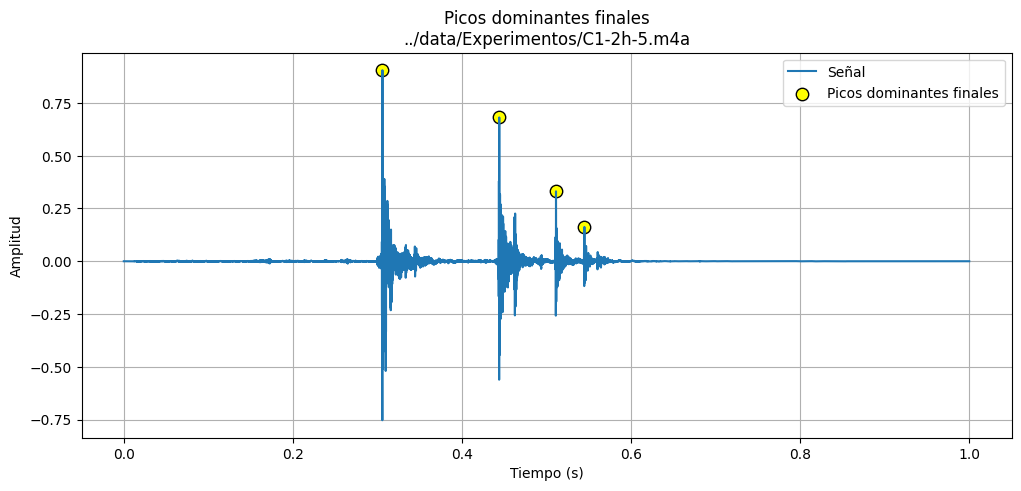

In [34]:
def plot_nm(n, m):
    base = "../data/Experimentos"
    fname = f"C1-{n}h-{m}.m4a" # n: horas descargadas, m: número de experimento
    audio_path = f"{base}/{fname}"

    print("Graficando:", audio_path)
    # Extract data once (optimized - no redundant loading)
    t, y, sr, peaks, times, amps = extract_dominant_peaks(audio_path)
    # Plot using pre-extracted data
    plot_audio_peaks_from_data(t, y, sr, peaks, times, amps, f"\n{audio_path}")
plot_nm(2, 5)